In [11]:
#importing liibraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
#dataset: marks out of 100
data = {
    'Student': ['Alice', 'Bob', 'Carol', 'Dave', 'Eve'],
    'Math': [88, 72, 95, 60, 78],
    'Science': [79, 85, 90, 55, 82],
    'English': [92, 68, 75, 70, 88],
    'History': [75, 60, 80, 65, 72],
    'Coding': [95, 90, 88, 55, 85]
}

df = pd.DataFrame(data).set_index('Student')
subjects =  df.columns.tolist()
students = df.index.tolist()

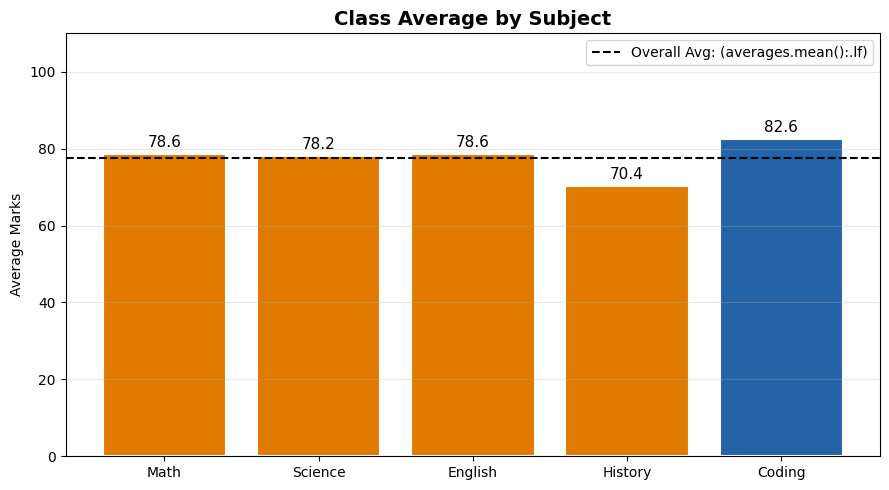

<Figure size 640x480 with 0 Axes>

In [13]:
#subject-wise class average (Bar Chart)
fig, ax = plt.subplots(figsize = (9, 5))
averages = df.mean()
colour = ['#2563A8' if v >= 80 else '#E07B00' if v >= 70 else '#C0392B' for v in averages]

bars = ax.bar(subjects, averages, color = colour, edgecolor = 'white', lw=1.5)

for bar, val in zip(bars, averages):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{val:.1f}', ha='center', va='bottom', fontsize=11)

ax.axhline(averages.mean(), color='black', linestyle='--', lw=1.5, label=f'Overall Avg: (averages.mean():.lf)')
ax.set_title('Class Average by Subject', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Marks')
ax.set_ylim(0, 110)
ax.legend()
ax.grid(axis = 'y', alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig('Class Average by Subject.png', dpi=150, bbox_inches='tight', facecolor='white')

Score Distribution per Student

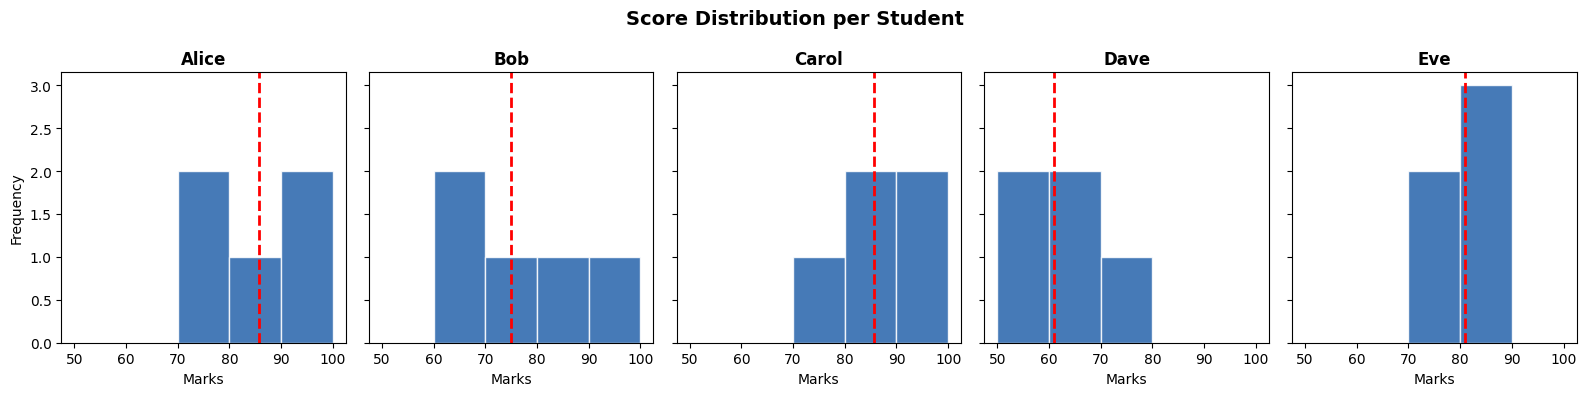

In [14]:
fig, axes = plt.subplots(1, len(students), figsize=(16, 4), sharey=True, sharex=True)

fig.suptitle('Score Distribution per Student', fontsize=14, fontweight='bold')

for ax, student in zip (axes, students):
    scores = df.loc[student].values
    ax.hist(scores, bins = 5, range=(50, 100), color='#2563AB', edgecolor = 'white', alpha = 0.85)
    ax.axvline(scores.mean(), color='red', lw=2, linestyle='--')
    ax.set_title(student, fontweight='bold')
    ax.set_xlabel('Marks')
    if ax == axes[0]:
        ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('Score Distribution per Student.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

Student Comparison (Multi-Line Chart)

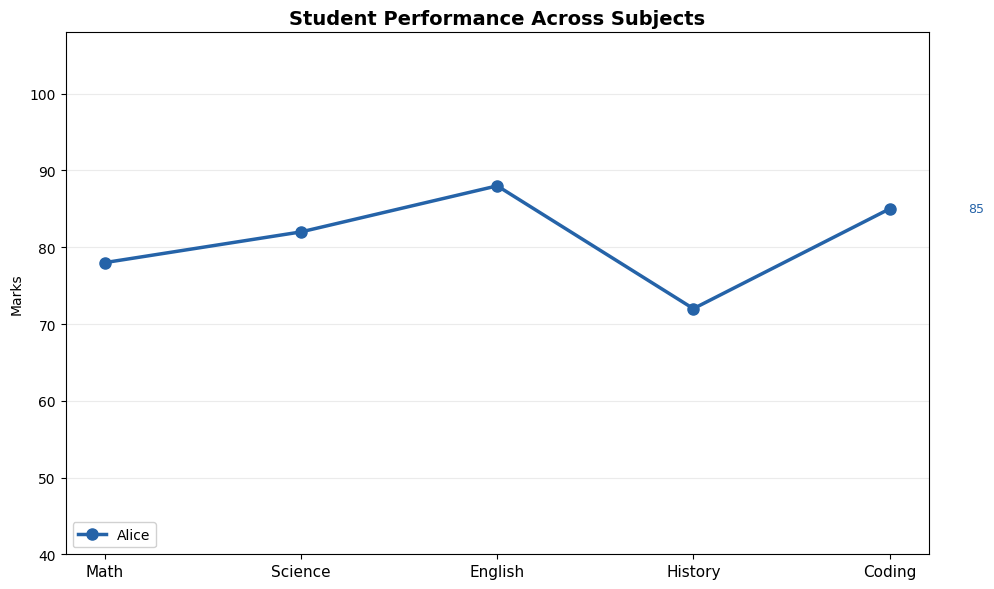

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [15]:
colours = ['#2563A8', '#E07B00', '#1A7A4A', '#C0392B', '#8E44AD']
x = range(len(subjects))
fig, ax = plt.subplots(figsize=(10, 6))
for students, colour in zip(students, colours):
    scores = df.loc[student].values
    ax.plot(x, scores, marker='o', linewidth=2.5, color=colour, label=students, markersize=8)
    ax.annotate(f'{scores[-1]}',
                xy = (len(x) - 1, scores[-1]),
                xytext = (len(x) - 0.6, scores[-1]),
                fontsize=9, color = colour, va='center')

    ax.set_xticks(x)
    ax.set_xticklabels(subjects, fontsize=11)
    ax.set_ylim(40, 108)
    ax.set_title('Student Performance Across Subjects', fontsize=14, fontweight='bold')
    ax.set_ylabel('Marks')
    ax.legend(loc='lower left', framealpha=0.9)
    ax.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.savefig('Student Performance Across Subjects.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

Combined Report Figure with Annotations and Export

/tmp/ipykernel_2159/2404699204.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot([df[s].values for s in subjects], labels = subjects, patch_artist=True, medianprops={'color':'red', 'lw':2})


Report saved: student_report.png


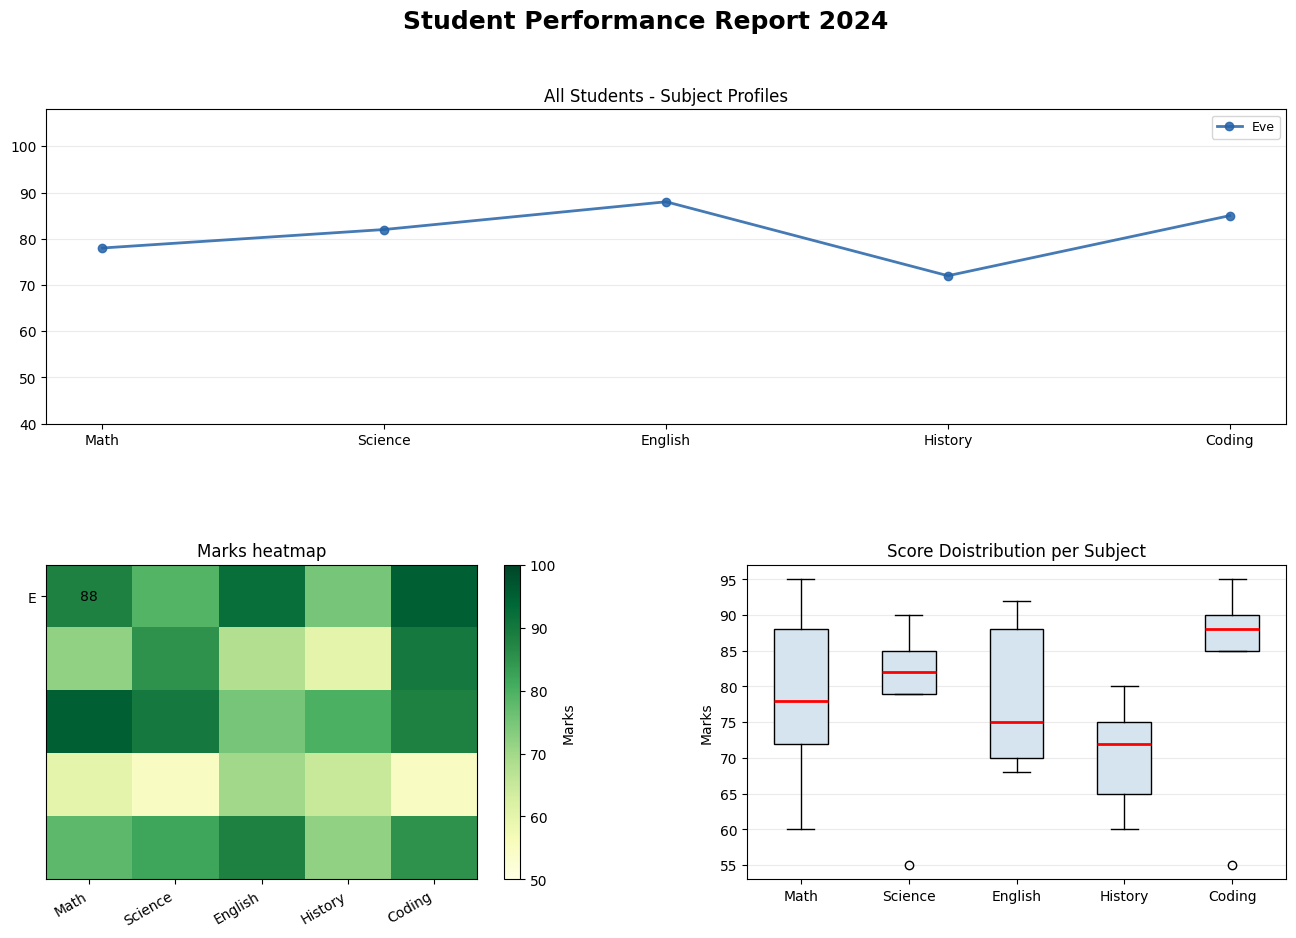

In [27]:
fig = plt.figure(figsize=(16, 10))

fig.suptitle('Student Performance Report 2024', fontsize = 18, fontweight='bold')

gs = plt.GridSpec(2, 2, hspace=0.45, wspace=0.3)
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1,1])

colours = ['#2563A8','#E07B00','#1A7A4A','#C0392B','#8E44AD']

x = range(len(subjects))

for students, colour in zip(students, colours):
    ax1.plot(x, df.loc[student].values, marker='o', linewidth=2, color = colour, label=student, alpha=0.85)

ax1.set_xticks(x); ax1.set_xticklabels(subjects)
ax1.legend(ncol=5, fontsize=9); ax1.set_title('All Students - Subject Profiles')

ax1.set_ylim(40, 108); ax1.grid(axis='y', alpha=0.25)

im = ax2.imshow(df.values, cmap='YlGn', aspect='auto', vmin=50, vmax=100)

ax2.set_xticks(range(len(subjects))); ax2.set_xticklabels(subjects, rotation = 30, ha='right')

ax2.set_yticks(range(len(students))); ax2.set_yticklabels(students)

for i in range(len(students)):
    for j in range(len(students)):
        ax2.text(j, i, str(df.iloc[i, j]), ha='center', va='center', fontsize=10, color = 'black')

plt.colorbar(im, ax= ax2, label='Marks'); ax2.set_title('Marks heatmap')

bp = ax3.boxplot([df[s].values for s in subjects], labels = subjects, patch_artist=True, medianprops={'color':'red', 'lw':2})
[p.set_facecolor('#D6E4F0') for p in bp['boxes']]
ax3.set_title('Score Doistribution per Subject')
ax3.set_ylabel('Marks'); ax3.grid(axis='y', alpha=0.25)

plt.savefig('student_report.png', dpi=200, bbox_inches='tight', facecolor='white')

plt.savefig('Student Performance Report 2024.png', dpi=150, bbox_inches='tight', facecolor='white')

print('Report saved: student_report.png')